In [13]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [ ]:
conn = sqlite3.connect('../db.sqlite3')
query = """
SELECT 
    ro.id as order_id,
    ro.datetime as order_datetime,
    roi.id as orderitem_id,
    roi.quantity,
    roi.product_id,
    rp.name as product_name,
    rp.price as product_price
FROM restaurant_order ro
JOIN restaurant_orderitem roi ON ro.id = roi.order_id
JOIN restaurant_product rp ON roi.product_id = rp.id
"""
 
df = pd.read_sql_query(query, conn)

conn.close()

df.to_csv('../data/restaurant_data.csv', index=False)

data = pd.read_csv('../data/restaurant_data.csv')

print(f"Total rows in dataframe: {len(data)}")
print(data.head())

Total rows in dataframe: 74818
   order_id       order_datetime  orderitem_id  quantity  product_id  \
0         1  2019-08-03 20:25:00             1         2           6   
1         1  2019-08-03 20:25:00             2         1         240   
2         1  2019-08-03 20:25:00             3         1          19   
3         1  2019-08-03 20:25:00             4         1          36   
4         1  2019-08-03 20:25:00             5         1         111   

          product_name  product_price  
0        Plain Papadum           0.80  
1     King Prawn Balti          12.95  
2          Garlic Naan           2.95  
3        Mushroom Rice           3.95  
4  Paneer Tikka Masala           8.95  


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

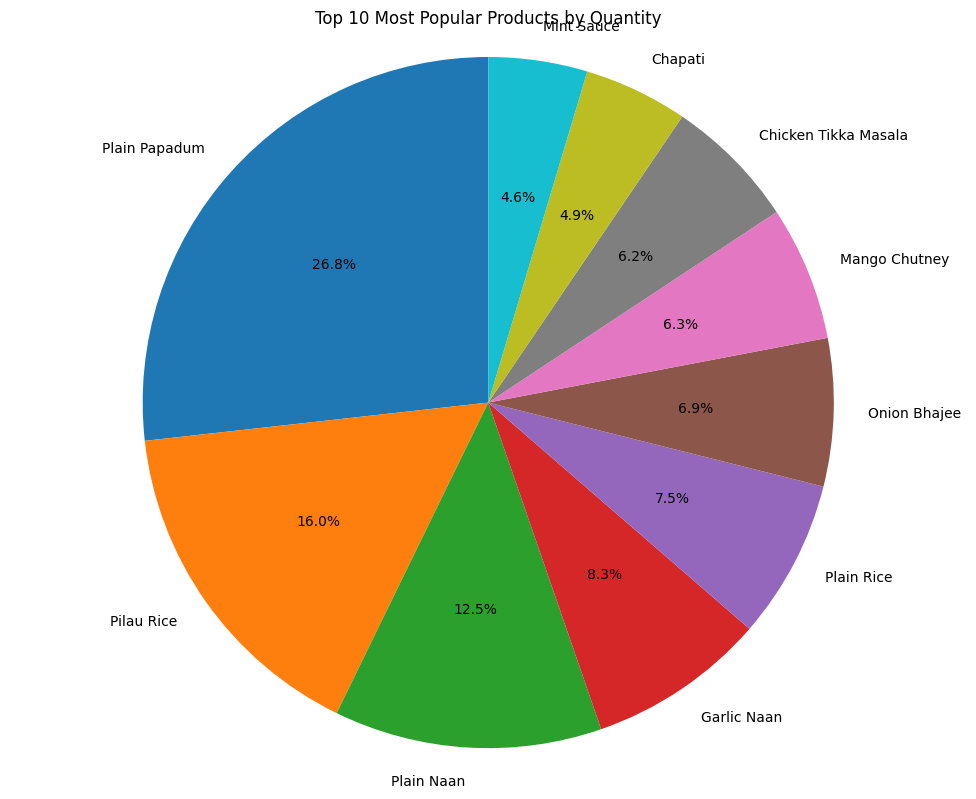


Top 10 Products by Quantity:
product_name
Plain Papadum           10648
Pilau Rice               6367
Plain Naan               4983
Garlic Naan              3318
Plain Rice               2964
Onion Bhajee             2749
Mango Chutney            2504
Chicken Tikka Masala     2473
Chapati                  1935
Mint Sauce               1840
Name: quantity, dtype: int64


In [ ]:
product_quantity = data.groupby('product_name')['quantity'].sum().sort_values(ascending=False)
top_10_quantity = product_quantity.head(10)

plt.figure(figsize=(10, 8))
plt.pie(top_10_quantity.values, labels=top_10_quantity.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 10 Most Popular Products by Quantity')
plt.axis('equal')
plt.tight_layout()
plt.savefig('../demo/pie_quantity.png')
plt.show()

print("\nTop 10 Products by Quantity:")
print(top_10_quantity)

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

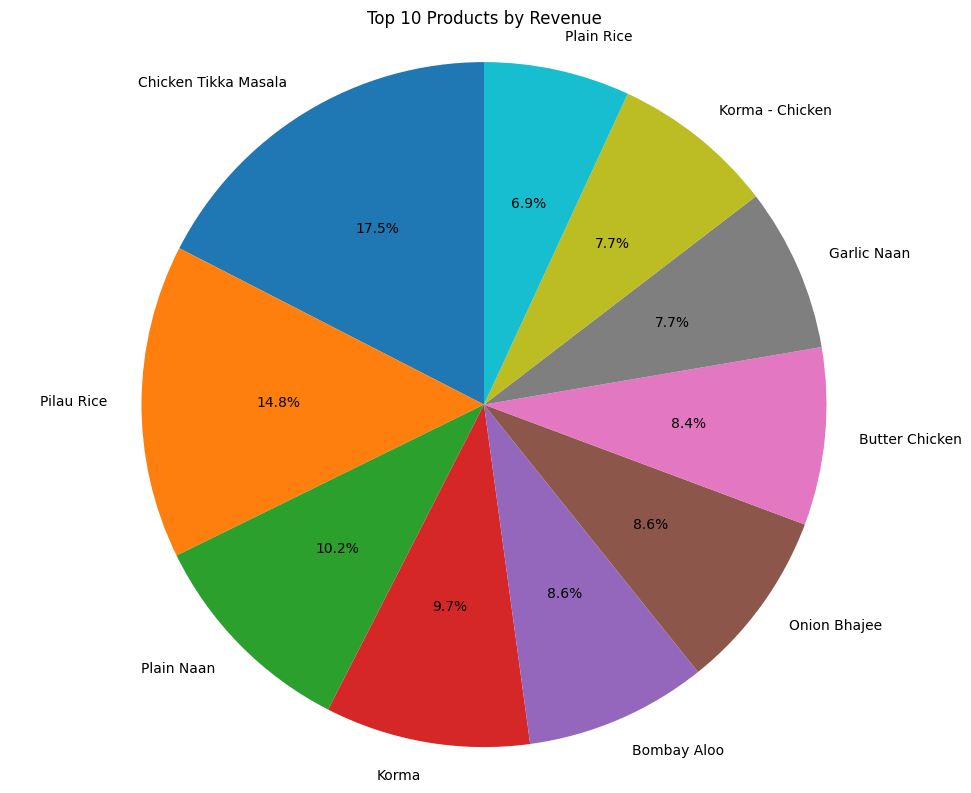


Top 10 Products by Revenue:
product_name
Chicken Tikka Masala    22133.35
Pilau Rice              18782.65
Plain Naan              12955.80
Korma                   12261.50
Bombay Aloo             10894.45
Onion Bhajee            10858.55
Butter Chicken          10626.60
Garlic Naan              9788.10
Korma - Chicken          9764.45
Plain Rice               8743.80
Name: item_price, dtype: float64


In [18]:
data['item_price'] = data['product_price'] * data['quantity']

product_revenue = data.groupby('product_name')['item_price'].sum().sort_values(ascending=False)
top_10_revenue = product_revenue.head(10)

plt.figure(figsize=(10, 8))
plt.pie(top_10_revenue.values, labels=top_10_revenue.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 10 Products by Revenue')
plt.axis('equal')
plt.tight_layout()
plt.savefig('../demo/pie_revenue.png')
plt.show()

print("\nTop 10 Products by Revenue:")
print(top_10_revenue)

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

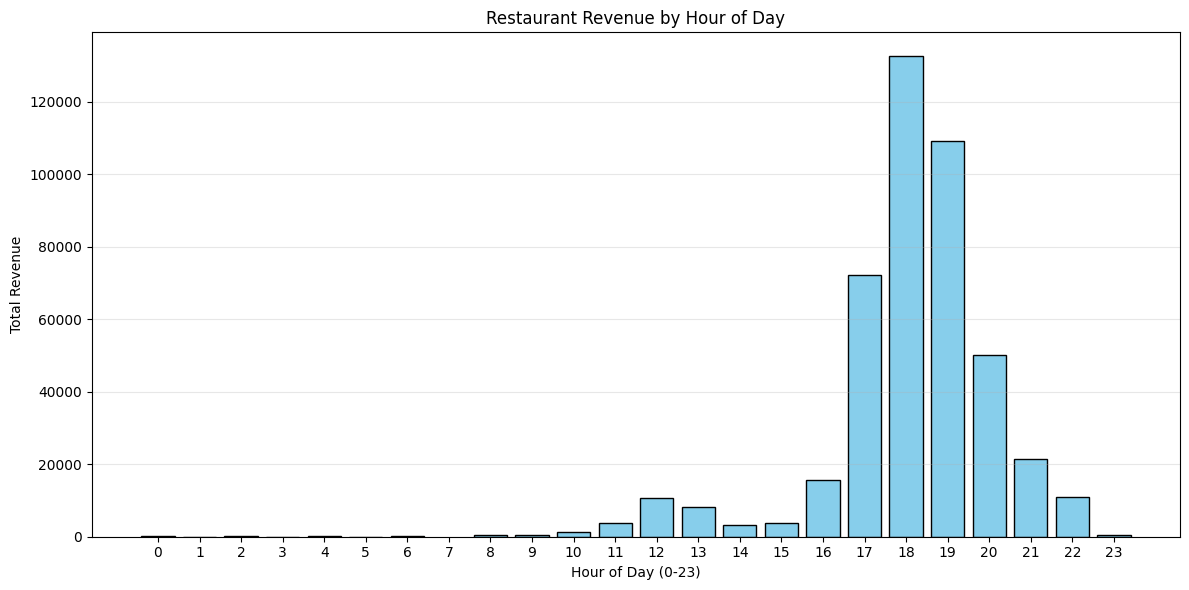


Revenue by Hour:
order_hour
0        177.95
1         54.65
2        199.25
3          8.90
4         63.45
5         57.40
6        121.60
8        447.70
9        570.60
10      1250.35
11      3807.05
12     10565.85
13      8282.65
14      3343.55
15      3781.70
16     15634.75
17     72110.20
18    132462.50
19    109045.05
20     50218.25
21     21480.30
22     11001.50
23       373.25
Name: item_price, dtype: float64


In [21]:

data['order_datetime'] = pd.to_datetime(data['order_datetime'])
data['order_hour'] = data['order_datetime'].dt.hour

revenue_by_hour = data.groupby('order_hour')['item_price'].sum().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(revenue_by_hour.index, revenue_by_hour.values, color='skyblue', edgecolor='black')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Total Revenue')
plt.title('Restaurant Revenue by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../demo/bar_hourly.png')
plt.show()

print("\nRevenue by Hour:")
print(revenue_by_hour)

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

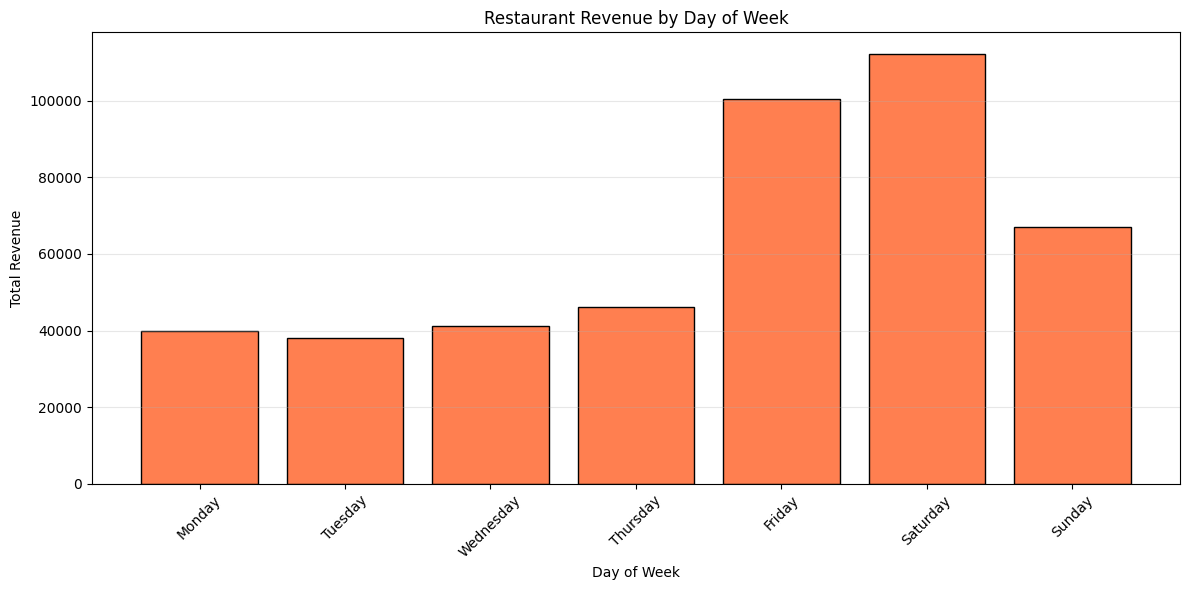


Revenue by Day of Week:
day_name
Monday        40008.30
Tuesday       38145.65
Wednesday     41246.20
Thursday      46021.55
Friday       100339.15
Saturday     112191.65
Sunday        67105.95
Name: item_price, dtype: float64


In [22]:
data['order_day_of_week'] = data['order_datetime'].dt.dayofweek

day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
             4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
data['day_name'] = data['order_day_of_week'].map(day_names)

revenue_by_day = data.groupby('day_name')['item_price'].sum()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_by_day = revenue_by_day.reindex(days_order)

plt.figure(figsize=(12, 6))
plt.bar(revenue_by_day.index, revenue_by_day.values, color='coral', edgecolor='black')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.title('Restaurant Revenue by Day of Week')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../demo/bar_weekly.png')
plt.show()

print("\nRevenue by Day of Week:")
print(revenue_by_day)